In [1]:
from sklearn.metrics import confusion_matrix
import numpy as np 
import os 
import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

/work/art-multimodal-benchmark/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = 'eva02_clip_336'
label = 'genre'

ds_test = datasets.load_from_disk(os.path.join('..', 'data', 'wikiart_filtered_test_split'))

y_true = ds_test[label]
y_pred = np.load(os.path.join('..', 'out', 'y_pred', f'{model_name}_{label}_y_pred.npy'))

conf_matrix = confusion_matrix(y_true, y_pred)

conf_matrix


array([[ 37,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  2, 236,   6,   3,  18,   0,   0,   0,   3,   0],
       [  0,  14, 364,  23,  13,  20,  21,  20,  25,   7],
       [  0,   1,   1,  91,   0,   0,   2,   2,   5,   0],
       [  0,  49,  17,   3, 675,   1,   0,   1,  23,   2],
       [  1,   0,   3,   0,   0,  57,   0,   0,   2,   0],
       [  0,   0,  60,   2,   0,   5, 624,  12,  41,   3],
       [  1,   0,   5,   6,   2,   2,   4, 262,   6,   0],
       [  2,   8,   8,   2,   3,  12,  19,   3, 181,   1],
       [  1,   0,   1,   1,   0,   1,   0,   0,   0, 126]])

In [4]:
labels = np.unique(ds_test[label])
target_names = [ds_test.features[label].int2str(int(i)) for i in labels]

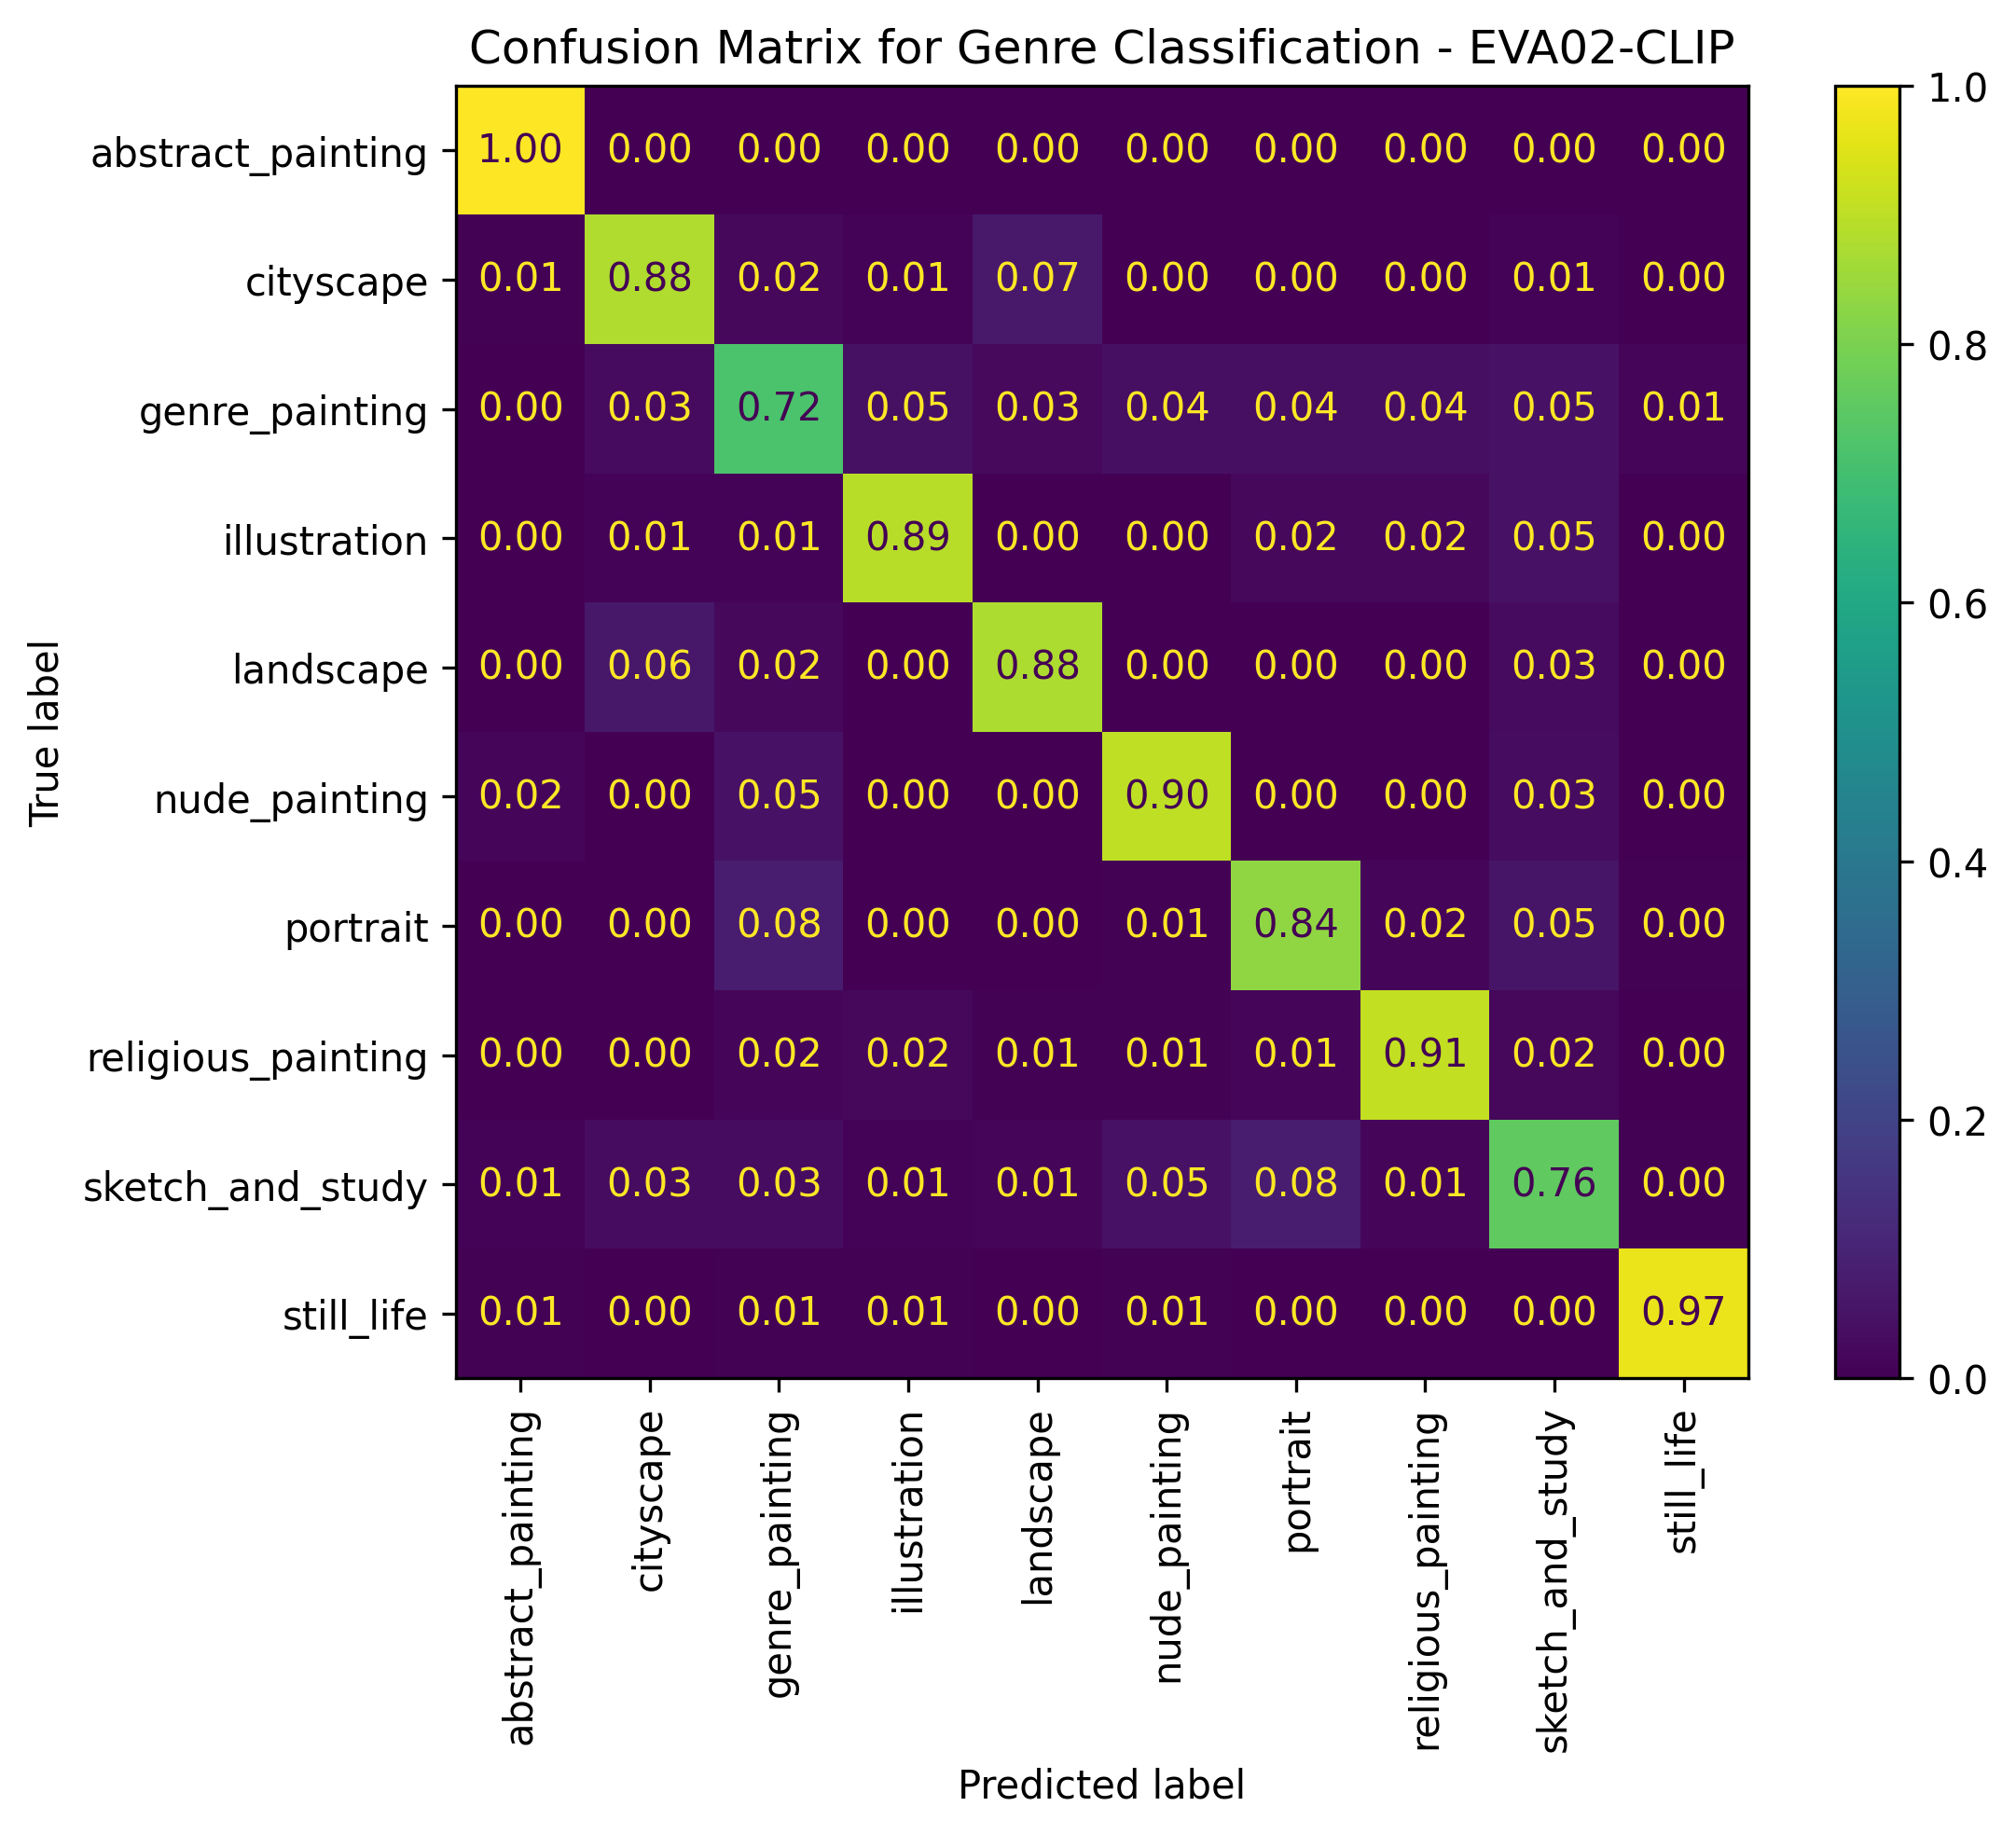

In [10]:
fig, ax = plt.subplots(figsize=(8,6), dpi=300)

display = ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=target_names,
    normalize='true',
    ax=ax,              # ← move ax here so it draws on YOUR figure
    values_format='.2f'
)

ax.set(title='Confusion Matrix for Genre Classification - EVA02-CLIP')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.savefig('conf_matrix_eva.png', bbox_inches='tight', dpi=300)

In [11]:
ds_full = datasets.load_from_disk(os.path.join('..', 'data', 'wikiart_filtered_remapped_FINAL'))

In [12]:
len(ds_full)

33595

In [1]:
import datasets 
import os 

/work/art-multimodal-benchmark/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
wikidata_impr = datasets.load_from_disk(os.path.join('..', 'data', 'wikidata_remapped_impr_subset'))

In [3]:
len(wikidata_impr)

3101

In [4]:
wikidata_impr['artist'].features

ClassLabel(names=['Alfred Sisley', 'Camille Pissarro', 'Eugène Louis Boudin', 'Paul Cézanne', 'Édouard Manet'])